# Post-API benchmark analysis (offline)

This notebook loads **`run_dataset.py` JSON** artifacts under a multi-archetype dataset root (e.g. `full_dataset/`) and runs a **threshold sweep framework** with no API calls and no rescoring.

**What is being measured**

- **Selected** — the superscore winner (`score` in each JSON).
- **Oracle (explored)** — within `superscore.explored_scores_full`, the best **`fraction_improved`** among rows that were already marked **`valid`** at run time (feasible ∧ guards as then computed).
- **τ sweep** — fraction of pair-runs where `valid ∧ fraction_improved ≥ τ`. Compare **selected** vs **oracle** to see if selection leaves headroom on the logged tree (on your full run they coincide: mean oracle − selected = 0).

**Official success** in the bar chart is the logged `score.success` (cluster uses `target_response ≤ 0`; others use the baked-in fraction thresholds from `queries.py` / `analysis/sweep.py` — **shape_niceness** uses worst-6 mean NPI as primary and a **0.02** success fraction after the benchmark update).

Reusable code lives in **`analysis/sweep.py`** and **`analysis/plots.py`**.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Repo root on sys.path (works if cwd is repo or notebooks/)
REPO = Path.cwd().resolve()
if not (REPO / "analysis").is_dir():
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from analysis.plots import (
    apply_plot_style,
    fig_ecdf_feasible_oracle_vs_selected,
    fig_ecdf_oracle,
    fig_heatmap_oracle_pass,
    fig_hist_oracle_vs_selected,
    fig_modality_comparison_bars,
    fig_oracle_marginal_sensitivity,
    fig_scatter_feasible_oracle_vs_selected,
    fig_scatter_selected_vs_oracle,
    fig_threshold_curves,
    fig_threshold_curves_guard_agnostic_oracle,
    fig_threshold_offline_tau_reselection,
    fig_shape_niceness_offline_tau,
    fig_violin_oracle_by_modality,
)
from analysis.sweep import (
    ARCHETYPE_ORDER,
    OFFICIAL_FRACTION_THRESHOLDS,
    group_paths,
    load_all_records,
    selection_gap_summary,
)

apply_plot_style()

# --- configure ---
RESULTS_ROOT = REPO / "full_dataset"
QUERY_TYPE = "vague"
TAU_STEP_FINE = 0.02   # threshold curves
TAU_STEP_COARSE = 0.05  # marginal derivative (smoother steps)

# Plot-time official τ overrides (no API): reference vertical lines and counterfactual
# modality bars use ``valid`` ∧ ``fraction_improved`` ≥ τ for listed archetypes.
# Use ``None`` to rely solely on ``analysis/sweep.OFFICIAL_FRACTION_THRESHOLDS``.
OFFICIAL_TAU_OVERRIDES: dict | None = {"shape_niceness": 0.02}

print("REPO =", REPO)
print("RESULTS_ROOT =", RESULTS_ROOT)

REPO = /Users/cat2510/MMIO
RESULTS_ROOT = /Users/cat2510/MMIO/full_dataset


In [2]:
records = load_all_records(RESULTS_ROOT, query_type=QUERY_TYPE)
paths_by_arch_mod = group_paths(records)

# --- shape_niceness: newer run outside RESULTS_ROOT (marker-free + new primary) ---
# Threshold-curve figures read ``paths_by_arch_mod`` only; other cells that use
# ``records`` / PairRecord paths still see shape rows from RESULTS_ROOT.
SHAPE_NICENESS_RESULTS_ROOT = REPO / "out/runs/shape_niceness_marker_free_vague"


def _shape_niceness_run_json_paths(results_subdir: str) -> list[Path]:
    pdir = SHAPE_NICENESS_RESULTS_ROOT / results_subdir
    if not pdir.is_dir():
        return []
    # Pair-run results only — exclude aggregate.json and full trajectories
    # (``*_trajectory.json`` is a JSON list, not a dict; it breaks sweeps).
    return sorted(
        p for p in pdir.glob("*.json")
        if p.name != "aggregate.json"
        and not p.name.endswith("_trajectory.json")
    )


if SHAPE_NICENESS_RESULTS_ROOT.is_dir():
    mm_p = _shape_niceness_run_json_paths("multimodal")
    to_p = _shape_niceness_run_json_paths("tools_only")
    if mm_p:
        paths_by_arch_mod[("shape_niceness", "multimodal")] = mm_p
    if to_p:
        paths_by_arch_mod[("shape_niceness", "tools_only")] = to_p
    print(
        f"Shape niceness JSON paths overridden → {SHAPE_NICENESS_RESULTS_ROOT} "
        f"(multimodal n={len(mm_p)}, tools_only n={len(to_p)})"
    )
else:
    print(
        f"Note: {SHAPE_NICENESS_RESULTS_ROOT} not found — "
        "shape_niceness plots use RESULTS_ROOT paths."
    )

print(f"Loaded {len(records)} pair-run JSON files")
print("Official fraction thresholds (from analysis/sweep.py, mirrors queries.py):", OFFICIAL_FRACTION_THRESHOLDS)
print("Archetypes:", ARCHETYPE_ORDER)
print("\nSelection gap (oracle best − selected fraction_improved):")
print(selection_gap_summary(records))
print(
    "\n(selection_gap_summary uses all PairRecords from RESULTS_ROOT; "
    "shape_niceness rows there may still reference old paths — τ curves use "
    "the override above.)"
)

Shape niceness JSON paths overridden → /Users/cat2510/MMIO/out/runs/shape_niceness_marker_free_vague (multimodal n=30, tools_only n=30)
Loaded 240 pair-run JSON files
Official fraction thresholds (from analysis/sweep.py, mirrors queries.py): {'coverage_gap': 0.3, 'contiguity': 0.5, 'shape_niceness': 0.02}
Archetypes: ('cluster', 'coverage_gap', 'contiguity', 'shape_niceness')

Selection gap (oracle best − selected fraction_improved):
{'mean_oracle_minus_selected': 0.0, 'frac_strictly_positive_gap': 0.0, 'max_gap': 0.0, 'mean_feasible_oracle_minus_selected': 0.10439316517325752, 'frac_feasible_oracle_strictly_above_selected': 0.2125, 'max_feasible_oracle_gap': 1.0}

(selection_gap_summary uses all PairRecords from RESULTS_ROOT; shape_niceness rows there may still reference old paths — τ curves use the override above.)


## 1. Success rate vs threshold τ

**One row per archetype.** **Multimodal** and **tools_only** are **overlaid** on the same axes (blue = MM, orange = TO). **Solid** = selected solution passes `valid ∧ fraction_improved ≥ τ`; **dashed** = oracle over feasible explores. The **x-axis is cropped per archetype** (shape niceness stops at τ = 0.10 where the curves are already flat at zero). If the official fraction bar lies past the right edge, a text note marks it instead of a vertical line.

Tall plateau at high τ means many runs achieved large fractional primary improvement; a cliff just left of the official bar means success is sensitive to small changes in τ.

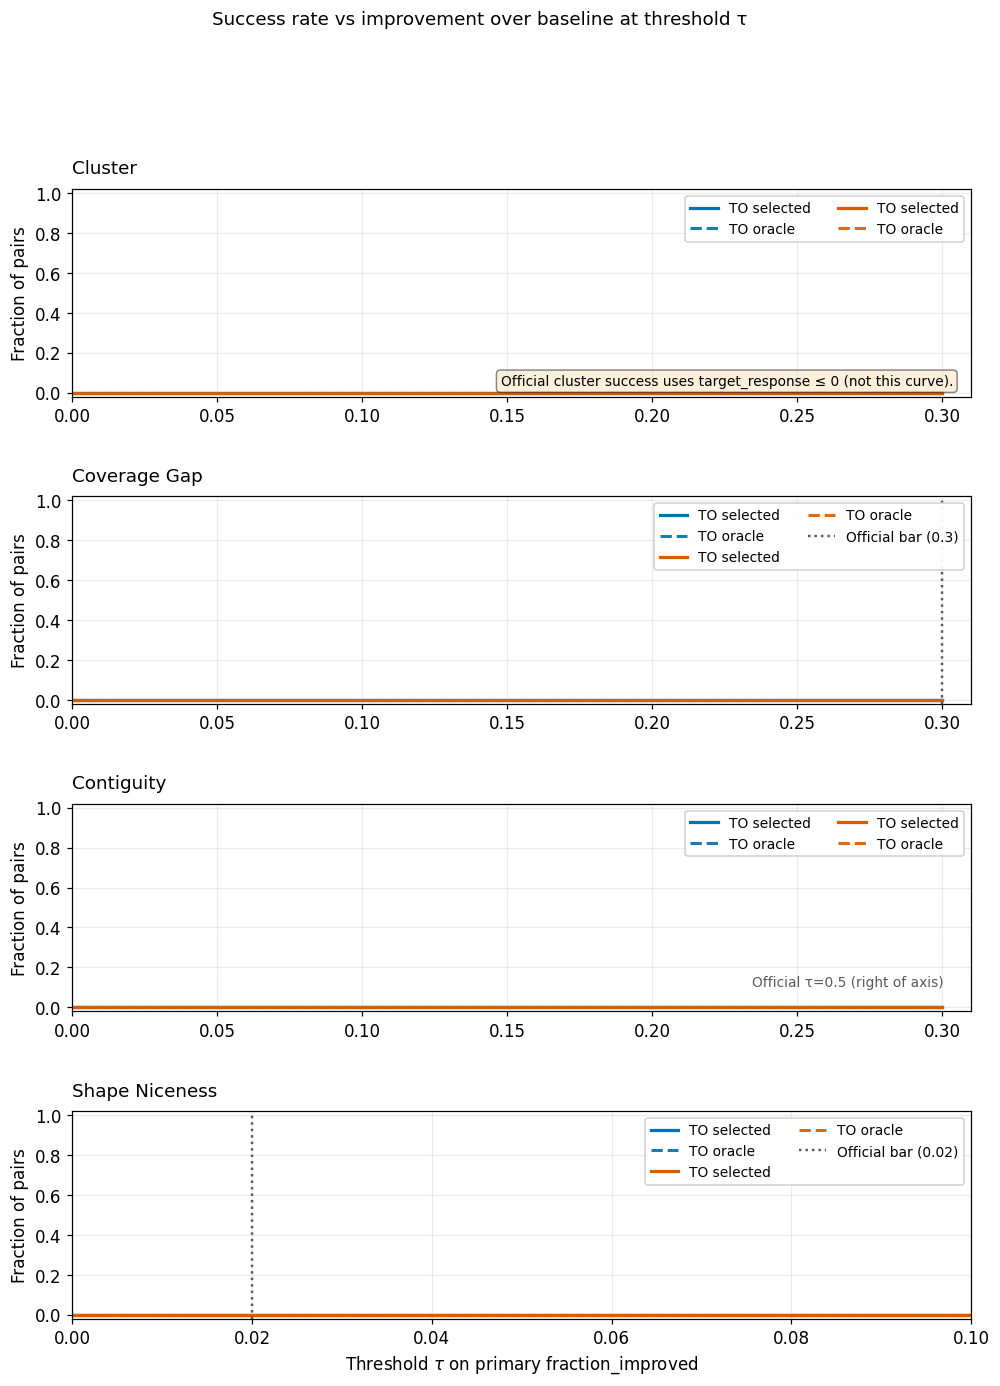

In [3]:
fig = fig_threshold_curves(
    paths_by_arch_mod,
    tau_step=TAU_STEP_FINE,
    official_threshold_overrides=OFFICIAL_TAU_OVERRIDES,
)
plt.show()

## 1b. Guard-agnostic feasible oracle (non-trivial vs selected)

The **valid** oracle (§1) matches **selected** on `fraction_improved` in your runs because superscore already maximises that among **valid** logged states.

Here the **oracle** is the maximum `fraction_improved` over **all logged feasible** explores, **ignoring** `valid` (i.e. ignoring guard satisfaction). The **selected** curve still requires `valid ∧ fraction ≥ τ`.

`PairRecord` also stores `violation_sum_at_max_feasible_fraction` vs `selected_total_guard_violation` for guard-margin work. **Global** regret vs a MIP optimum is not in JSON — see `analysis/optimum_regret.py`.

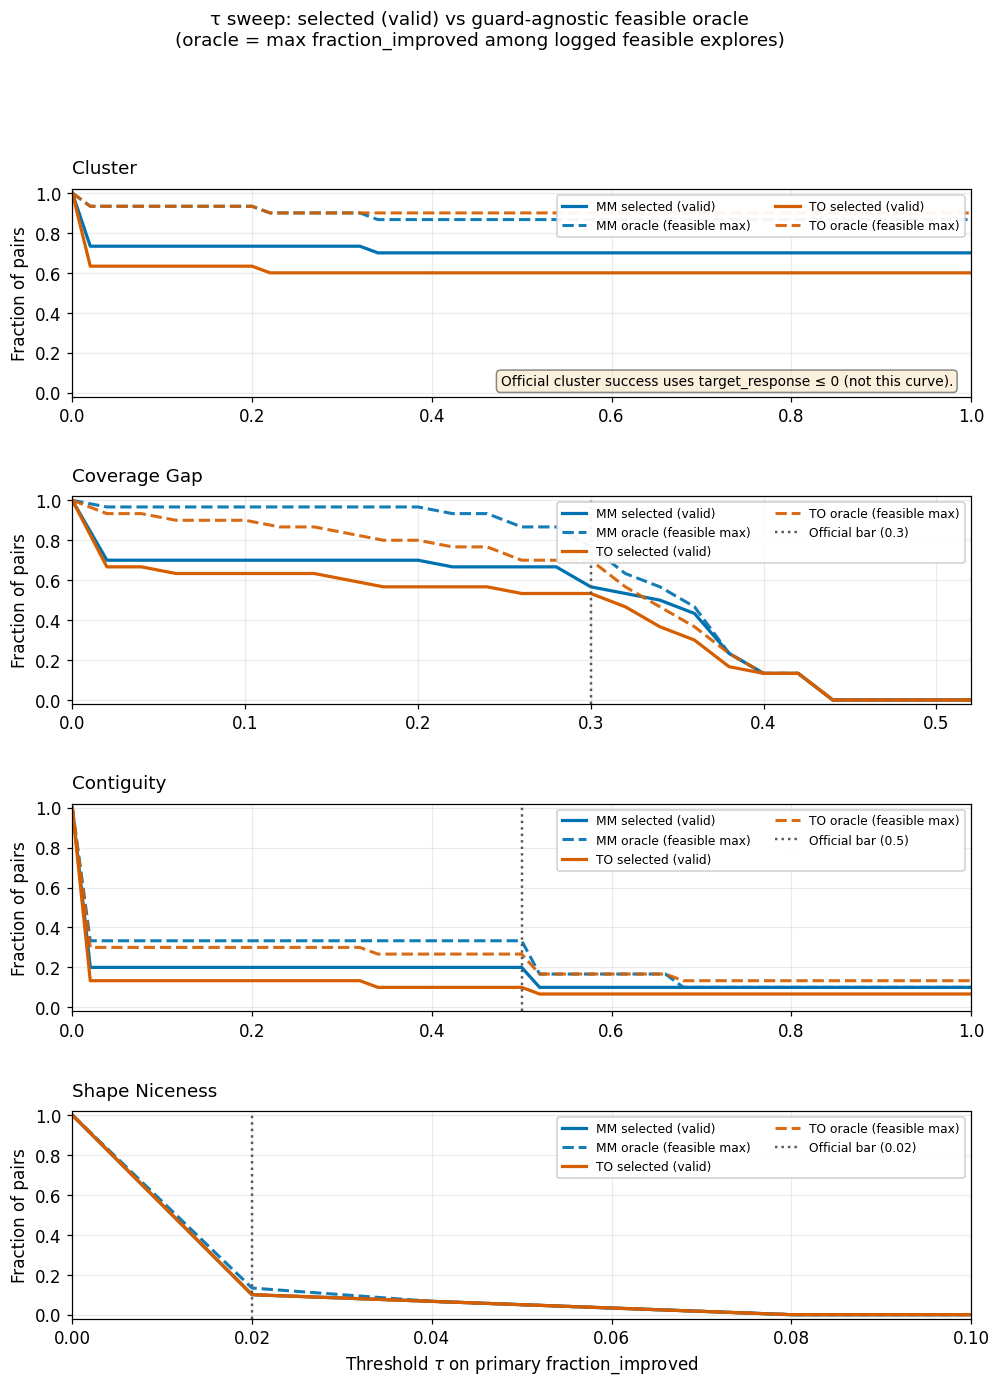

In [4]:
fig = fig_threshold_curves_guard_agnostic_oracle(
    paths_by_arch_mod,
    tau_step=TAU_STEP_FINE,
    official_threshold_overrides=OFFICIAL_TAU_OVERRIDES,
)
plt.show()

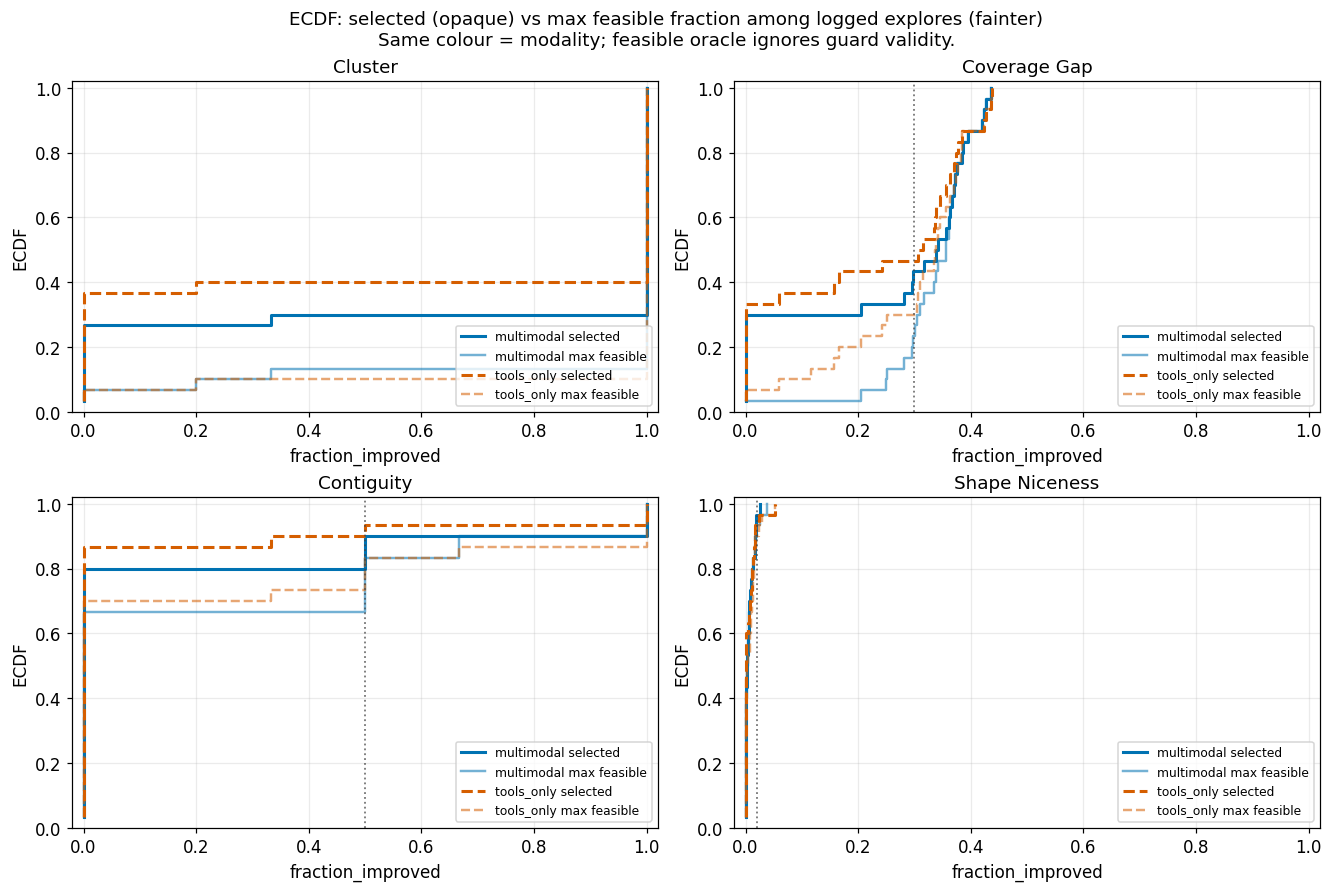

In [5]:
fig = fig_ecdf_feasible_oracle_vs_selected(records)
plt.show()

## 7. Official benchmark success (logged)

Side-by-side **multimodal** vs **tools_only** mean `score.success` per archetype — this is the headline benchmark, not the τ sweep.

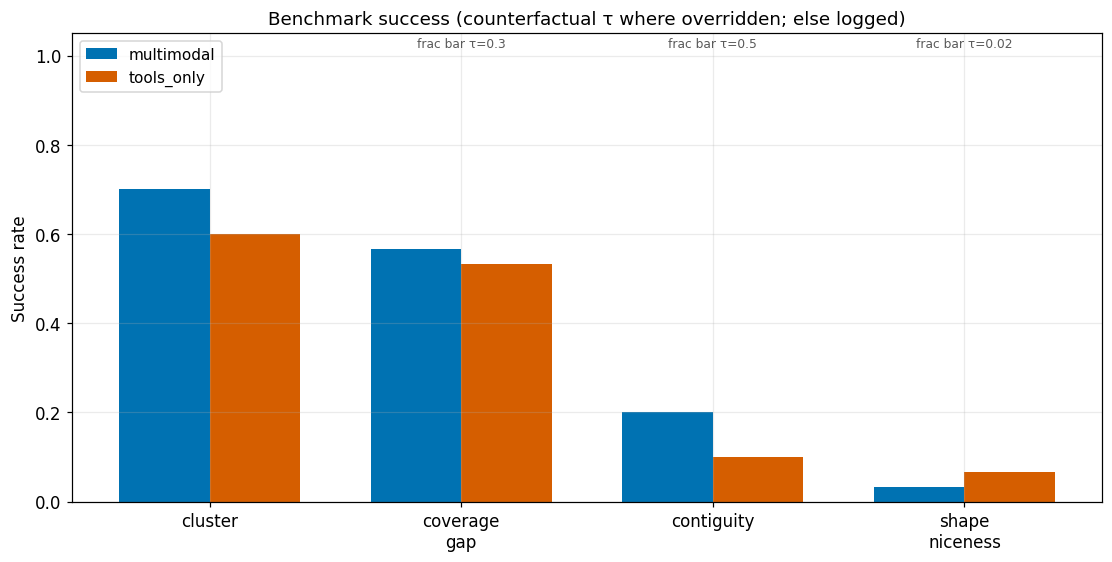

In [6]:
fig = fig_modality_comparison_bars(
    records,
    official_threshold_overrides=OFFICIAL_TAU_OVERRIDES,
)
plt.show()

## 8. Export figures (optional)

Uncomment to write PNGs next to this notebook.

In [ ]:
# OUT = Path.cwd() / "post_api_figures"
# OUT.mkdir(exist_ok=True)
# fig_threshold_curves(paths_by_arch_mod, tau_step=TAU_STEP_FINE).savefig(OUT / "01_threshold_curves.png", bbox_inches="tight")
# fig_threshold_curves_guard_agnostic_oracle(paths_by_arch_mod, tau_step=TAU_STEP_FINE).savefig(OUT / "01b_threshold_guard_agnostic.png", bbox_inches="tight")
# fig_threshold_offline_tau_reselection(paths_by_arch_mod, tau_step=TAU_STEP_FINE).savefig(OUT / "01_offline_tau_reselection.png", bbox_inches="tight")
# fig_ecdf_feasible_oracle_vs_selected(records).savefig(OUT / "01c_ecdf_feasible_oracle.png", bbox_inches="tight")
# fig_scatter_feasible_oracle_vs_selected(records).savefig(OUT / "01d_scatter_feasible_oracle.png", bbox_inches="tight")
# fig_ecdf_oracle(records).savefig(OUT / "02_ecdf_oracle.png", bbox_inches="tight")
# fig_hist_oracle_vs_selected(records).savefig(OUT / "03_hist_oracle_selected.png", bbox_inches="tight")
# fig_scatter_selected_vs_oracle(records).savefig(OUT / "04_scatter.png", bbox_inches="tight")
# fig_oracle_marginal_sensitivity(paths_by_arch_mod, tau_step=TAU_STEP_COARSE).savefig(OUT / "05_marginal_oracle.png", bbox_inches="tight")
# fig_violin_oracle_by_modality(records).savefig(OUT / "06_violin_oracle.png", bbox_inches="tight")
# fig_modality_comparison_bars(records).savefig(OUT / "07_official_success.png", bbox_inches="tight")
# fig_heatmap_oracle_pass(paths_by_arch_mod, modality="multimodal", tau_step=0.05).savefig(OUT / "08_heatmap_oracle_mm.png", bbox_inches="tight")

## Shape niceness — offline replay rescoring

The main τ-sweep figures above still use only the logged JSON `fraction_improved`; they do **not** auto-update when you regenerate this CSV.

In [7]:
import csv
import numpy as np
from pathlib import Path

SHAPE_OFFLINE_DIR = REPO / "full_dataset/shape_niceness/offline_rescore_vague"
RESCORE_CSV = SHAPE_OFFLINE_DIR / "rescore.csv"

if not RESCORE_CSV.is_file():
    raise FileNotFoundError(
        f"Missing {RESCORE_CSV}. Run from repo root:\n"
        "  python scripts/audit_and_rescore_shape_niceness.py"
    )


def _f(row: dict, key: str) -> float:
    v = row.get(key, "")
    if v is None or v == "":
        return float("nan")
    return float(v)


_rows: list[dict] = []
with open(RESCORE_CSV, newline="") as f:
    for row in csv.DictReader(f):
        if row.get("error"):
            continue
        _rows.append(row)

_by_mod = {m: sum(1 for r in _rows if r.get("modality") == m) for m in ("multimodal", "tools_only")}
print(f"Loaded {len(_rows)} rows from {RESCORE_CSV.relative_to(REPO)}")
print("By modality:", _by_mod)

Loaded 60 rows from full_dataset/shape_niceness/offline_rescore_vague/rescore.csv
By modality: {'multimodal': 30, 'tools_only': 30}


1. delta_npi_mean_worst6 (from rescore.csv: delta_npi_mean_worst6)

For baseline, compute each opened catchment’s NPI, take the six worst (highest) NPI values, average them → baseline_npi_mean_worst6.
For selected, do the same rule on the selected plan → selected_npi_mean_worst6.
Delta = selected − baseline on those two global “mean of worst 6” numbers.
So it answers: “After selection, is the overall ‘bad tail’ of NPI better or worse than baseline’s bad tail?”
The six worst sites can be different in baseline vs selected, because the rule is applied separately to each plan.

2. delta_npi_mean_on_baseline_worst6_sites

First, find the six catchments where baseline NPI was worst (highest).
Then look only at those same six IDs on both plans and take the mean of (selected NPI − baseline NPI) on those sites (enrich_with_topk_deltas in shape_niceness_replay_metrics.py).
So it answers: “On the specific places baseline was already terrible, did the selected plan improve NPI?”
It’s a fixed slice of geography defined by baseline, not “worst 6 under the new plan.”

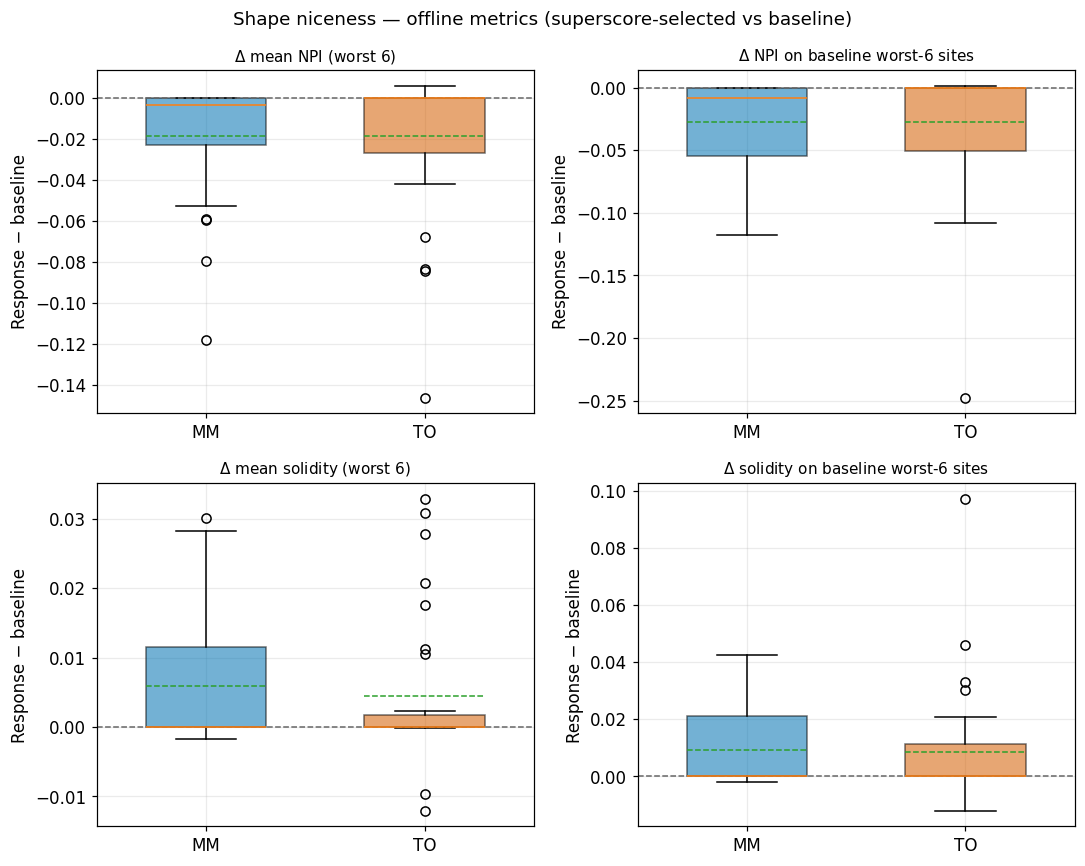

In [8]:
from analysis.plots import COLOR_MM, COLOR_TO

METRICS = [
    ("delta_npi_mean_worst6", r"$\Delta$ mean NPI (worst 6)"),
    ("delta_npi_mean_on_baseline_worst6_sites", r"$\Delta$ NPI on baseline worst-6 sites"),
    ("delta_solidity_mean_worst6", r"$\Delta$ mean solidity (worst 6)"),
    ("delta_solidity_mean_on_baseline_worst6_sites", r"$\Delta$ solidity on baseline worst-6 sites"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()
for ax, (col, title) in zip(axes, METRICS):
    mm = [_f(r, col) for r in _rows if r.get("modality") == "multimodal"]
    to = [_f(r, col) for r in _rows if r.get("modality") == "tools_only"]
    pos = [1, 2]
    bp = ax.boxplot(
        [mm, to],
        positions=pos,
        widths=0.55,
        patch_artist=True,
        showmeans=True,
        meanline=True,
    )
    bp["boxes"][0].set_facecolor(COLOR_MM)
    bp["boxes"][0].set_alpha(0.55)
    bp["boxes"][1].set_facecolor(COLOR_TO)
    bp["boxes"][1].set_alpha(0.55)
    ax.axhline(0.0, color="0.4", ls="--", lw=1.0)
    ax.set_xticks(pos)
    ax.set_xticklabels(["MM", "TO"])
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Response − baseline")
fig.suptitle("Shape niceness — offline metrics (superscore-selected vs baseline)", fontsize=12)
fig.tight_layout()
plt.show()